In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kaggle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
kaggle.api.authenticate()
kaggle.api.dataset_download_files('asaniczka/top-spotify-songs-in-73-countries-daily-updated', path= '.', unzip = True)

Dataset URL: https://www.kaggle.com/datasets/asaniczka/top-spotify-songs-in-73-countries-daily-updated


In [5]:
pd.set_option('display.float_format', lambda x: f'{x:0.3f}')

In [7]:
df = pd.read_csv("universal_top_spotify_songs.csv")

print("Columns:", df.columns)


Columns: Index(['spotify_id', 'name', 'artists', 'daily_rank', 'daily_movement',
       'weekly_movement', 'country', 'snapshot_date', 'popularity',
       'is_explicit', 'duration_ms', 'album_name', 'album_release_date',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature'],
      dtype='object')


In [9]:
# 3. Basic setup and helpers
# ================================
# Identify ID and country columns (dataset can use 'country' or 'country_name')
if "spotify_id" in df.columns:
    track_id_cols = ["spotify_id"]
else:
    # fallback: use name+artists as a composite ID
    track_id_cols = ["name", "artists"]

country_col = "country_name" if "country_name" in df.columns else "country"

# Audio features (your list)
audio_features = [
    "energy",
    "danceability",
    "valence",
    "tempo",
    "acousticness",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
]

# Decide which column to use as "streams"
# If dataset has a 'streams' column, we use it.
# Otherwise, we fall back to 'popularity' as a proxy.
if "streams" in df.columns:
    streams_col = "streams"
else:
    streams_col = "popularity"  # proxy for popularity / exposure

In [10]:
# ================================
# 4. Build SONG-LEVEL table
# ================================
# We want:
# - one row per song
# - aggregated audio features
# - popularity metrics:
#   * streams_metric (sum of streams or mean popularity)
#   * peak_rank (min daily_rank across all countries/days)
#   * num_countries (number of distinct countries where track appeared)

agg_dict = {feat: "mean" for feat in audio_features}

# streams vs popularity aggregation
if streams_col == "streams":
    agg_dict[streams_col] = "sum"  # total streams
else:
    agg_dict[streams_col] = "mean"  # average popularity across days/countries

# daily rank (peak chart rank)
agg_dict["daily_rank"] = "min"

# number of countries
def nunique(series):
    return series.nunique()

agg_dict[country_col] = nunique

song_level = (
    df.groupby(track_id_cols)
      .agg(agg_dict)
      .reset_index()
      .rename(
          columns={
              streams_col: "streams_metric",   # total streams or avg popularity
              "daily_rank": "peak_rank",
              country_col: "num_countries",
          }
      )
)

print("\nSong-level table head:")
print(song_level.head())


Song-level table head:
               spotify_id  energy  danceability  valence   tempo  \
0  000n6Lx4yqUAslF1x3JeFY   0.728         0.676    0.938 174.089   
1  001TLpmtuQMWJYyE7q9ayM   0.567         0.823    0.545 136.006   
2  003vvx7Niy0yvhvHt4a68B   0.911         0.352    0.236 148.033   
3  005L1nFVHdbcd7gvtK7zrh   0.453         0.854    0.082 137.930   
4  005cocyIL36CVjjtUEdVSq   0.436         0.786    0.734 120.100   

   acousticness  instrumentalness  liveness  loudness  speechiness  \
0         0.395             0.000     0.059    -7.661        0.097   
1         0.123             0.000     0.113    -9.571        0.216   
2         0.001             0.000     0.099    -5.230        0.075   
3         0.314             0.000     0.104    -9.620        0.136   
4         0.411             0.000     0.107    -9.802        0.043   

   streams_metric  peak_rank  num_countries  
0          62.000         14              1  
1          33.000         23              2  
2       


Correlation matrix (audio features vs popularity metrics):
                  energy  danceability  valence  tempo  acousticness  \
energy             1.000         0.169    0.349  0.119        -0.501   
danceability       0.169         1.000    0.362 -0.107        -0.242   
valence            0.349         0.362    1.000  0.052        -0.087   
tempo              0.119        -0.107    0.052  1.000        -0.089   
acousticness      -0.501        -0.242   -0.087 -0.089         1.000   
instrumentalness  -0.137        -0.037   -0.092  0.011         0.027   
liveness           0.155        -0.122    0.030  0.022        -0.041   
loudness           0.702         0.147    0.250  0.066        -0.335   
speechiness        0.012         0.150    0.035  0.020        -0.034   
streams_metric     0.046        -0.017    0.078 -0.010         0.048   
peak_rank         -0.049        -0.062   -0.014 -0.012         0.044   
num_countries     -0.017        -0.031   -0.024  0.000        -0.022   

   

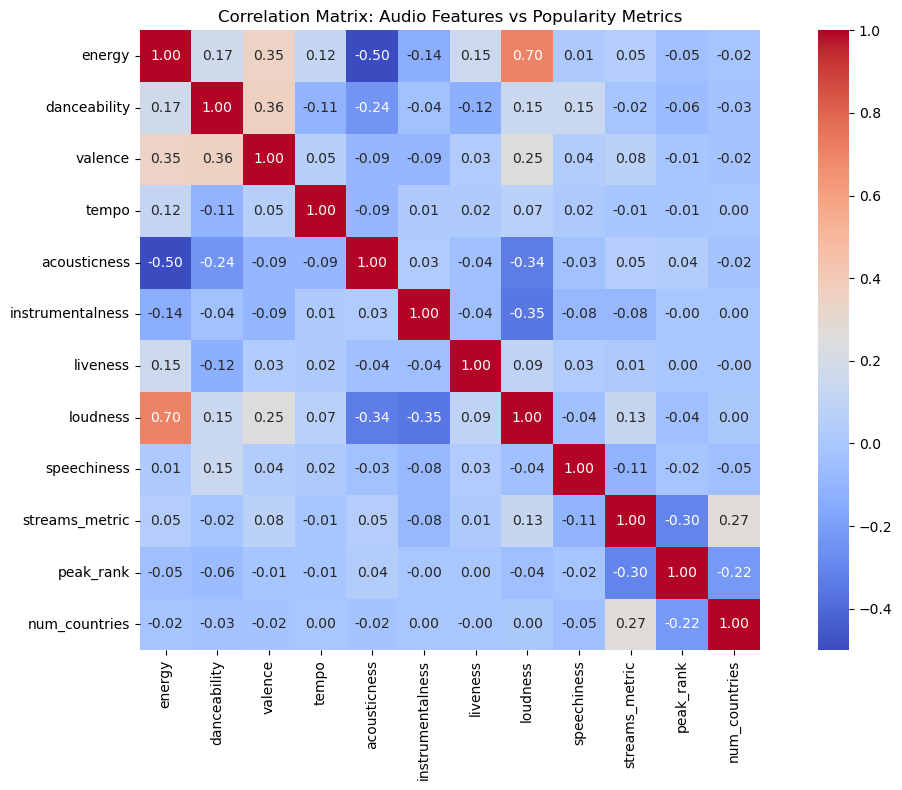


Audio features vs popularity metrics (subset of correlation matrix):
                  streams_metric  peak_rank  num_countries
loudness                   0.127     -0.045          0.005
valence                    0.078     -0.014         -0.024
acousticness               0.048      0.044         -0.022
energy                     0.046     -0.049         -0.017
liveness                   0.013      0.002         -0.002
tempo                     -0.010     -0.012          0.000
danceability              -0.017     -0.062         -0.031
instrumentalness          -0.084     -0.003          0.003
speechiness               -0.106     -0.017         -0.049


In [32]:
# ================================
# 5. Correlation Analysis (RQ1)
# ================================
corr_vars = audio_features + ["streams_metric", "peak_rank", "num_countries"]

corr_df = song_level[corr_vars].corr(method="pearson")

print("\nCorrelation matrix (audio features vs popularity metrics):")
print(corr_df)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix: Audio Features vs Popularity Metrics")
plt.tight_layout()
plt.show()

# If you want to see how strongly each feature correlates with popularity metrics only:
pop_metrics = ["streams_metric", "peak_rank", "num_countries"]
audio_corr_to_pop = corr_df.loc[audio_features, pop_metrics]
print("\nAudio features vs popularity metrics (subset of correlation matrix):")
print(audio_corr_to_pop.sort_values(by="streams_metric", ascending=False))




In [31]:
# ================================
# 6. Binary Classification Setup (RQ5)
#    Target: will a song chart in >= 10 countries?
# ================================
song_level["global_hit"] = (song_level["num_countries"] >= 10).astype(int)

X = song_level[["energy", "danceability", "valence", "loudness",
                "speechiness", "tempo", "acousticness"]].copy()
y = song_level["global_hit"]

# Drop rows with missing values in predictors or target
mask = X.notnull().all(axis=1) & y.notnull()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize for models that need scaling (logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# ================================
# 7. Logistic Regression (baseline interpretable model)
# ================================
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification report:")
print(classification_report(y_test, y_pred_lr, digits=3))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# Coefficients and Odds Ratios
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": log_reg.coef_[0],
})
coef_df["odds_ratio"] = np.exp(coef_df["coef"])

print("\nLogistic Regression Coefficients and Odds Ratios:")
print(coef_df.sort_values(by="odds_ratio", ascending=False))


=== Logistic Regression Performance ===
Accuracy: 0.9621080720480321

Classification report:
              precision    recall  f1-score   support

           0      0.962     1.000     0.981      7211
           1      0.000     0.000     0.000       284

    accuracy                          0.962      7495
   macro avg      0.481     0.500     0.490      7495
weighted avg      0.926     0.962     0.944      7495

Confusion matrix:
[[7211    0]
 [ 284    0]]

Logistic Regression Coefficients and Odds Ratios:
        feature   coef  odds_ratio
3      loudness  0.236       1.266
5         tempo -0.045       0.956
2       valence -0.101       0.904
1  danceability -0.142       0.868
6  acousticness -0.175       0.839
4   speechiness -0.187       0.830
0        energy -0.257       0.774


C:\Users\sebas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sebas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sebas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== Random Forest Performance ===
Accuracy: 0.9630420280186791

Classification report:
              precision    recall  f1-score   support

           0      0.965     0.998     0.981      7211
           1      0.600     0.074     0.132       284

    accuracy                          0.963      7495
   macro avg      0.782     0.536     0.556      7495
weighted avg      0.951     0.963     0.949      7495

Confusion matrix:
[[7197   14]
 [ 263   21]]

Random Forest feature importances:
        feature  importance
3      loudness       0.154
5         tempo       0.152
2       valence       0.143
6  acousticness       0.143
4   speechiness       0.140
1  danceability       0.136
0        energy       0.133


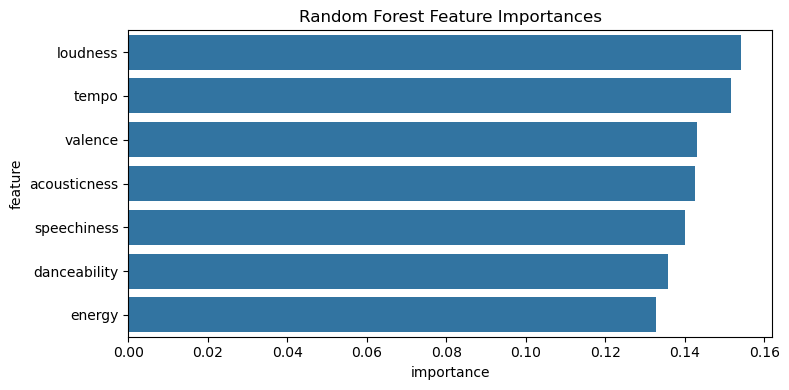

In [18]:
# ================================
# 8. Random Forest Classifier (non-linear model)
# ================================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)  # RF does not require scaling

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf, digits=3))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Feature importance
importances = rf.feature_importances_
fi_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances,
}).sort_values(by="importance", ascending=False)

print("\nRandom Forest feature importances:")
print(fi_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=fi_df, x="importance", y="feature")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()


In [19]:
# ================================
# 9. Country-level Profiles (for RQ3 & RQ4)
# ================================
# Compute mean audio features per country (Top 200 per country aggregated)
country_features = (
    df.groupby(country_col)[audio_features]
      .mean()
      .reset_index()
      .rename(columns={country_col: "country"})
)

print("\nCountry-level audio feature profiles:")
print(country_features.head())

X_country = country_features[audio_features]
scaler_country = StandardScaler()
X_country_scaled = scaler_country.fit_transform(X_country)


Country-level audio feature profiles:
  country  energy  danceability  valence   tempo  acousticness  \
0      AE   0.625         0.639    0.497 122.279         0.232   
1      AR   0.682         0.696    0.634 117.337         0.243   
2      AT   0.662         0.666    0.530 127.412         0.220   
3      AU   0.625         0.629    0.511 125.314         0.244   
4      BE   0.651         0.659    0.526 125.314         0.259   

   instrumentalness  liveness  loudness  speechiness  
0             0.018     0.165    -6.700        0.073  
1             0.027     0.192    -6.318        0.089  
2             0.024     0.174    -6.779        0.092  
3             0.012     0.159    -6.691        0.065  
4             0.034     0.159    -6.761        0.079  


C:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Cluster counts (countries per cluster):
cluster
0    14
1    21
2    28
3     8
4     1
Name: count, dtype: int64


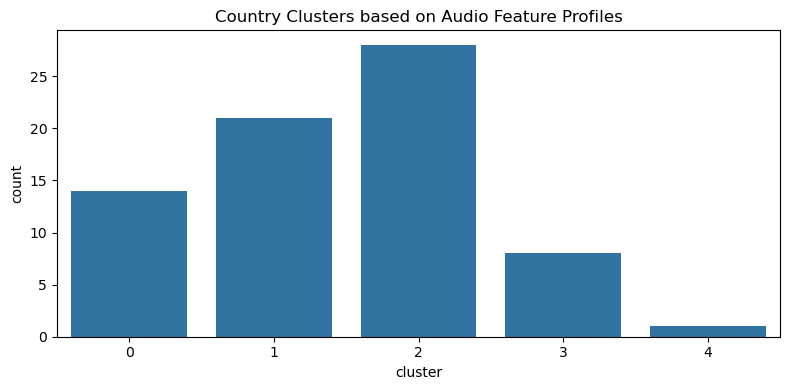

In [20]:
# ================================
# 10. K-Means Clustering on Countries
# ================================
# Choose K (e.g. 5 to roughly align with 5 broad regions)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
country_features["cluster"] = kmeans.fit_predict(X_country_scaled)

print("\nCluster counts (countries per cluster):")
print(country_features["cluster"].value_counts().sort_index())

plt.figure(figsize=(8, 4))
sns.countplot(data=country_features, x="cluster")
plt.title("Country Clusters based on Audio Feature Profiles")
plt.tight_layout()
plt.show()


Explained variance by PC1 and PC2: [0.38829077 0.20875089]


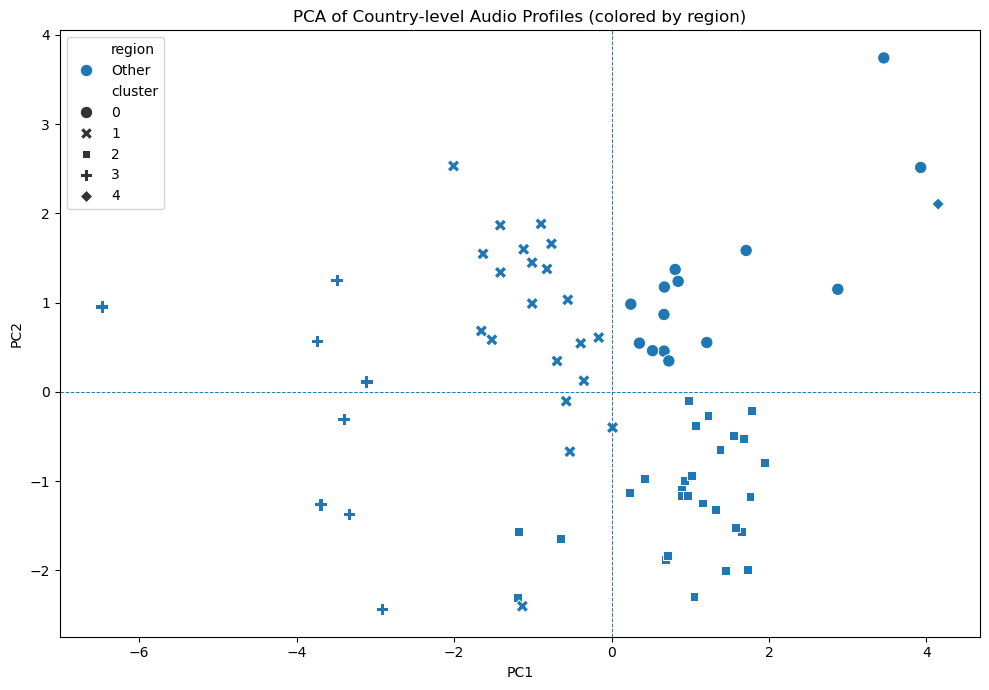

In [21]:
# ================================
# 11. PCA for 2D visualization, colored by region
# ================================
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_country_scaled)
country_features["PC1"] = pcs[:, 0]
country_features["PC2"] = pcs[:, 1]

print("\nExplained variance by PC1 and PC2:", pca.explained_variance_ratio_)

# --- Region mapping  ---

country_to_region = {
    # Latin America
    "Argentina": "Latin America",
    "Bolivia": "Latin America",
    "Brazil": "Latin America",
    "Chile": "Latin America",
    "Colombia": "Latin America",
    "Costa Rica": "Latin America",
    "Dominican Republic": "Latin America",
    "Ecuador": "Latin America",
    "Guatemala": "Latin America",
    "Honduras": "Latin America",
    "Mexico": "Latin America",
    "Nicaragua": "Latin America",
    "Panama": "Latin America",
    "Paraguay": "Latin America",
    "Peru": "Latin America",
    "Uruguay": "Latin America",
    "Venezuela": "Latin America",
    "El Salvador": "Latin America",

    # Europe
    "Austria": "Europe",
    "Belgium": "Europe",
    "Bulgaria": "Europe",
    "Belarus": "Europe",
    "Switzerland": "Europe",
    "Czech Republic": "Europe",
    "Germany": "Europe",
    "Denmark": "Europe",
    "Spain": "Europe",
    "Finland": "Europe",
    "France": "Europe",
    "United Kingdom": "Europe",
    "Greece": "Europe",
    "Estonia": "Europe",
    "Ireland": "Europe",
    "Iceland": "Europe",
    "Italy": "Europe",
    "Lithuania": "Europe",
    "Luxembourg": "Europe",
    "Latvia": "Europe",
    "Netherlands": "Europe",
    "Norway": "Europe",
    "Poland": "Europe",
    "Portugal": "Europe",
    "Romania": "Europe",
    "Slovakia": "Europe",
    "Sweden": "Europe",
    "Ukraine": "Europe",

    # Asia (non-MENA)
    "Hong Kong": "Asia",
    "Indonesia": "Asia",
    "India": "Asia",
    "Japan": "Asia",
    "South Korea": "Asia",
    "Kazakhstan": "Asia",
    "Malaysia": "Asia",
    "Philippines": "Asia",
    "Pakistan": "Asia",
    "Singapore": "Asia",
    "Thailand": "Asia",
    "Taiwan": "Asia",
    "Vietnam": "Asia",

    # North America (anglo)
    "Canada": "North America",
    "United States": "North America",

    # MENA (Middle East & North Africa)
    "United Arab Emirates": "MENA",
    "Saudi Arabia": "MENA",
    "Egypt": "MENA",
    "Morocco": "MENA",
    "Israel": "MENA",
    "Turkey": "MENA",

    # Other / Oceania / Africa outside MENA
    "Australia": "Other",
    "New Zealand": "Other",
    "Nigeria": "Other",
    "South Africa": "Other",

    # Fallback for the aggregate playlist
    "Global": "Global",
}

country_features["region"] = country_features["country"].map(country_to_region).fillna("Other")

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=country_features,
    x="PC1",
    y="PC2",
    hue="region",
    style="cluster",
    s=80,
)
plt.title("PCA of Country-level Audio Profiles (colored by region)")
plt.axhline(0, linestyle="--", linewidth=0.7)
plt.axvline(0, linestyle="--", linewidth=0.7)
plt.tight_layout()
plt.show()

Correlation matrix (subset):
                  energy  danceability  valence  tempo  acousticness  \
energy             1.000         0.169    0.349  0.119        -0.501   
danceability       0.169         1.000    0.362 -0.107        -0.242   
valence            0.349         0.362    1.000  0.052        -0.087   
tempo              0.119        -0.107    0.052  1.000        -0.089   
acousticness      -0.501        -0.242   -0.087 -0.089         1.000   
instrumentalness  -0.137        -0.037   -0.092  0.011         0.027   
liveness           0.155        -0.122    0.030  0.022        -0.041   
loudness           0.702         0.147    0.250  0.066        -0.335   
speechiness        0.012         0.150    0.035  0.020        -0.034   
streams_metric     0.046        -0.017    0.078 -0.010         0.048   
num_countries     -0.017        -0.031   -0.024  0.000        -0.022   

                  instrumentalness  liveness  loudness  speechiness  \
energy                      -0.137 

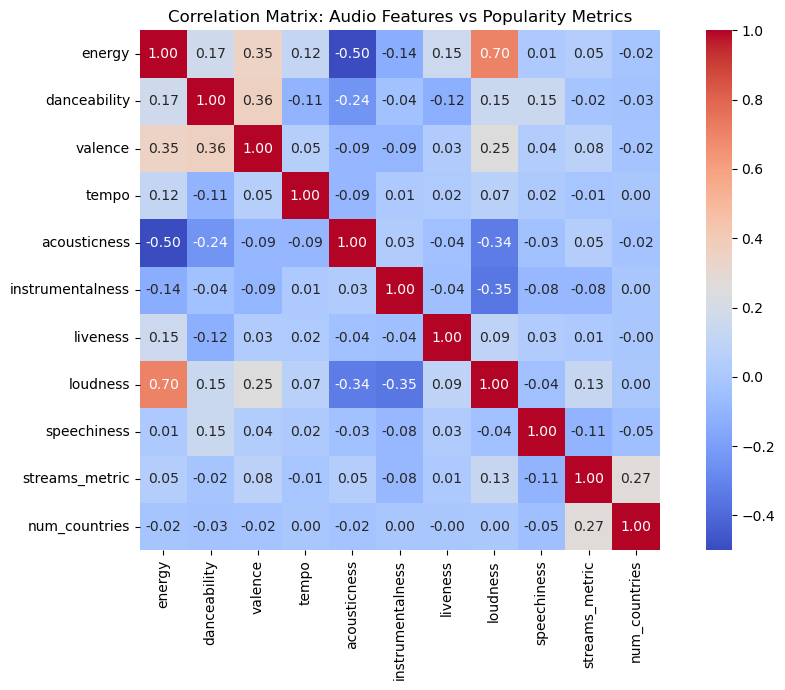


Correlation of audio features with popularity metrics:
                  streams_metric  num_countries
loudness                   0.127          0.005
valence                    0.078         -0.024
acousticness               0.048         -0.022
energy                     0.046         -0.017
liveness                   0.013         -0.002
tempo                     -0.010          0.000
danceability              -0.017         -0.031
instrumentalness          -0.084          0.003
speechiness               -0.106         -0.049


In [30]:
# RQ1: correlation audio features vs popularity (streams_metric y num_countries)
corr_vars = audio_features + ["streams_metric", "num_countries"]

corr_rq1 = song_level[corr_vars].corr(method="pearson")
print("Correlation matrix (subset):")
print(corr_rq1)

# Correlación de cada feature con streams_metric (popularidad)
corr_with_streams = corr_rq1["streams_metric"].loc[audio_features].sort_values(ascending=False)
print("\nCorrelation of audio features with streams_metric:")
print(corr_with_streams)

# Correlación de cada feature con num_countries (alcance global)
corr_with_countries = corr_rq1["num_countries"].loc[audio_features].sort_values(ascending=False)
print("\nCorrelation of audio features with num_countries:")
print(corr_with_countries)

# Heatmap para el reporte
plt.figure(figsize=(10, 7))
sns.heatmap(corr_rq1, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix: Audio Features vs Popularity Metrics")
plt.tight_layout()
plt.show()
# Put everything in one clean table
corr_summary = pd.DataFrame({
    "feature": audio_features,
    "r_streams": [corr_rq1.loc[f, "streams_metric"] for f in audio_features],
    "r_num_countries": [corr_rq1.loc[f, "num_countries"] for f in audio_features],
})

# Show only correlations of audio features with popularity metrics
popularity_metrics = ["streams_metric", "num_countries"]  # add "peak_rank" if you have it

corr_popularity = corr_rq1.loc[audio_features, popularity_metrics]
print("\nCorrelation of audio features with popularity metrics:")
print(corr_popularity.sort_values(by="streams_metric", ascending=False))




Mean energy, danceability and num_countries by Top10 vs Non-Top10:
           energy  danceability  num_countries
Non-Top10   0.648         0.667          1.468
Top10       0.665         0.686          3.530

Percentage difference (Top10 vs Non-Top10) in energy, danceability, num_countries:
energy            2.500
danceability      2.770
num_countries   140.420
dtype: float64


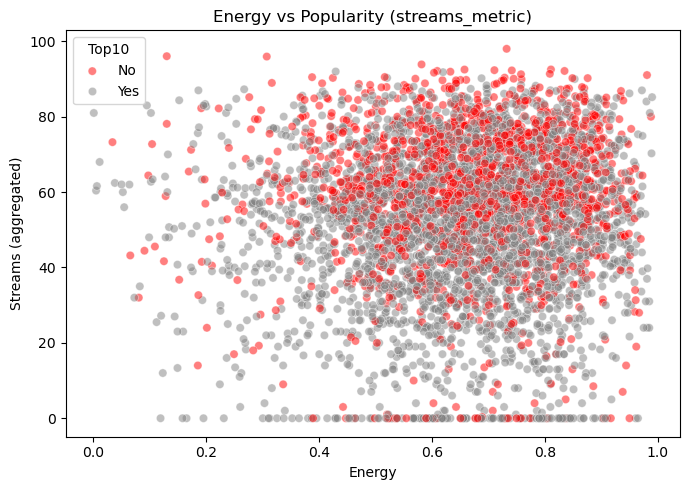

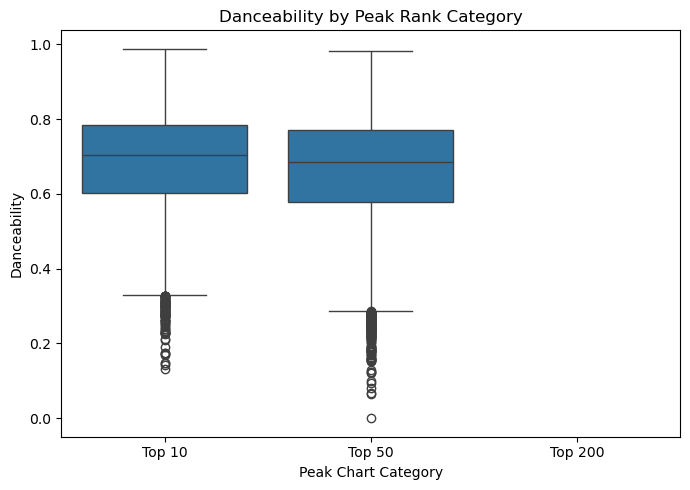

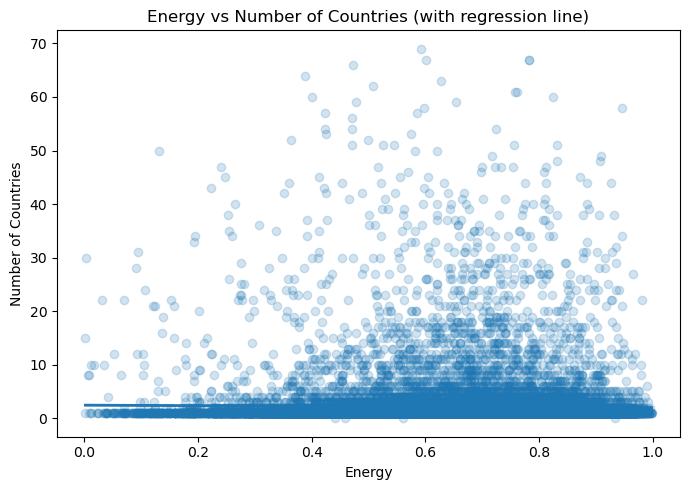

In [33]:
# RQ2Flag: canciones que alcanzan Top 10 en algún país/día
song_level["is_top10"] = (song_level["peak_rank"] <= 10).astype(int)

# Estadísticas de energía, danceability y alcance (num_countries)
cols_rq2 = ["energy", "danceability", "num_countries"]
group_rq2 = song_level.groupby("is_top10")[cols_rq2].mean()
group_rq2.index = ["Non-Top10", "Top10"]  # 0 -> Non-Top10, 1 -> Top10
print("\nMean energy, danceability and num_countries by Top10 vs Non-Top10:")
print(group_rq2)

# Diferencias porcentuales Top10 vs NonTop10
top10_means = group_rq2.loc["Top10"]
non_top10_means = group_rq2.loc["Non-Top10"]

pct_diff = (top10_means - non_top10_means) / non_top10_means * 100
print("\nPercentage difference (Top10 vs Non-Top10) in energy, danceability, num_countries:")
print(pct_diff.round(2))

# --- Plots sugeridos ---

# 1) Scatter: Energy vs streams_metric
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=song_level.sample(min(5000, len(song_level))),  # sample para que no sea enorme
    x="energy",
    y="streams_metric",
    hue="is_top10",
    alpha=0.5,
    palette={0: "gray", 1: "red"},
)
plt.title("Energy vs Popularity (streams_metric)")
plt.xlabel("Energy")
plt.ylabel("Streams (aggregated)")
plt.legend(title="Top10", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

# 2) Boxplot: danceability por categoría de ranking (Top 10, Top 50, Top 200)
def rank_category(rank):
    if rank <= 10:
        return "Top 10"
    elif rank <= 50:
        return "Top 50"
    else:
        return "Top 200"

song_level["rank_cat"] = song_level["peak_rank"].apply(rank_category)

plt.figure(figsize=(7, 5))
sns.boxplot(data=song_level, x="rank_cat", y="danceability", order=["Top 10", "Top 50", "Top 200"])
plt.title("Danceability by Peak Rank Category")
plt.xlabel("Peak Chart Category")
plt.ylabel("Danceability")
plt.tight_layout()
plt.show()

# 3) Regresión lineal simple energía vs num_countries
plt.figure(figsize=(7, 5))
sns.regplot(
    data=song_level,
    x="energy",
    y="num_countries",
    scatter_kws={"alpha": 0.2},
    line_kws={"linewidth": 2},
)
plt.title("Energy vs Number of Countries (with regression line)")
plt.xlabel("Energy")
plt.ylabel("Number of Countries")
plt.tight_layout()
plt.show()


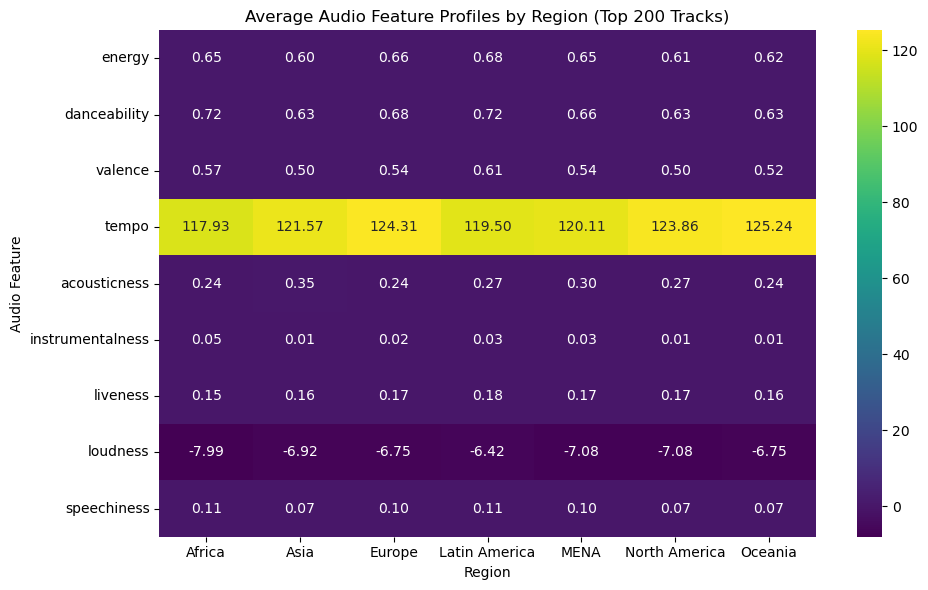

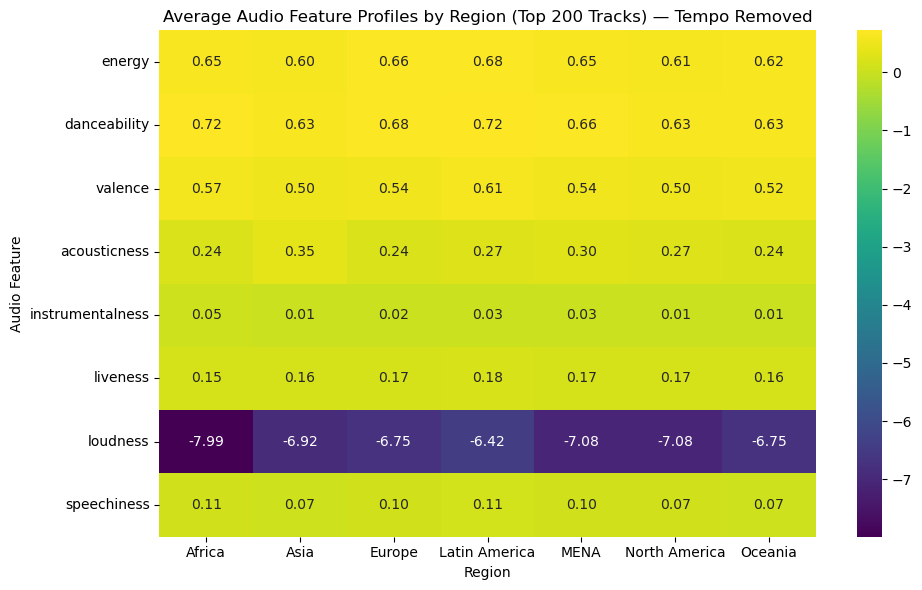

In [47]:
#crear columna de region
country_region_iso = {
    # Latin America
    "AR":"Latin America","BO":"Latin America","BR":"Latin America","CL":"Latin America",
    "CO":"Latin America","CR":"Latin America","DO":"Latin America","EC":"Latin America",
    "GT":"Latin America","HN":"Latin America","MX":"Latin America","NI":"Latin America",
    "PA":"Latin America","PE":"Latin America","PY":"Latin America","SV":"Latin America",
    "UY":"Latin America","VE":"Latin America",

    # North America
    "US":"North America","CA":"North America",

    # Europe
    "AT":"Europe","BE":"Europe","BG":"Europe","BY":"Europe","CH":"Europe","CZ":"Europe",
    "DE":"Europe","DK":"Europe","EE":"Europe","ES":"Europe","FI":"Europe","FR":"Europe",
    "GB":"Europe","GR":"Europe","HU":"Europe","IE":"Europe","IS":"Europe","IT":"Europe",
    "LT":"Europe","LU":"Europe","LV":"Europe","NL":"Europe","NO":"Europe","PL":"Europe",
    "PT":"Europe","RO":"Europe","SK":"Europe","SE":"Europe","UA":"Europe",

    # Asia
    "AE":"Asia","HK":"Asia","ID":"Asia","IL":"Asia","IN":"Asia","JP":"Asia","KR":"Asia",
    "KZ":"Asia","MY":"Asia","PH":"Asia","PK":"Asia","SG":"Asia","TH":"Asia","TW":"Asia",
    "VN":"Asia",

    # Middle East / North Africa (MENA)
    "TR":"MENA","EG":"MENA","SA":"MENA","MA":"MENA","AE":"MENA",  # AE moved here for accuracy

    # Sub-Saharan Africa
    "NG":"Africa","ZA":"Africa",

    # Oceania
    "AU":"Oceania","NZ":"Oceania",

    # Fallback for NA values or unknown
}


# -------------- 2) MAP REGION TO ORIGINAL DF -----------------
df["region"] = df["country"].map(country_region_iso).fillna("Other")


# -------------- 3) REBUILD COUNTRY FEATURES *AFTER* REGION EXISTS -----------------
country_features = (
    df.groupby("country")[audio_features].mean().reset_index()
)

country_features["region"] = country_features["country"].map(country_region_iso).fillna("Other")


# -------------- 4) CREATE REGION HEATMAP (NOW SHOULD WORK) -----------------
region_profiles = country_features.groupby("region")[audio_features].mean().round(3)

plt.figure(figsize=(10,6))
sns.heatmap(region_profiles.T, annot=True, fmt=".2f", cmap="viridis")
plt.title("Average Audio Feature Profiles by Region (Top 200 Tracks)")
plt.xlabel("Region")
plt.ylabel("Audio Feature")
plt.tight_layout()
plt.show()

# -------------- 4) REGION HEATMAP WITHOUT TEMPO -----------------

# Remove 'tempo' from visualization to avoid color scale distortion
audio_features_no_tempo = [f for f in audio_features if f != "tempo"]

region_profiles = (
    country_features.groupby("region")[audio_features_no_tempo].mean().round(3)
)

plt.figure(figsize=(10,6))
sns.heatmap(region_profiles.T, annot=True, fmt=".2f", cmap="viridis")
plt.title("Average Audio Feature Profiles by Region (Top 200 Tracks) — Tempo Removed")
plt.xlabel("Region")
plt.ylabel("Audio Feature")
plt.tight_layout()
plt.show()






C:\Users\sebas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


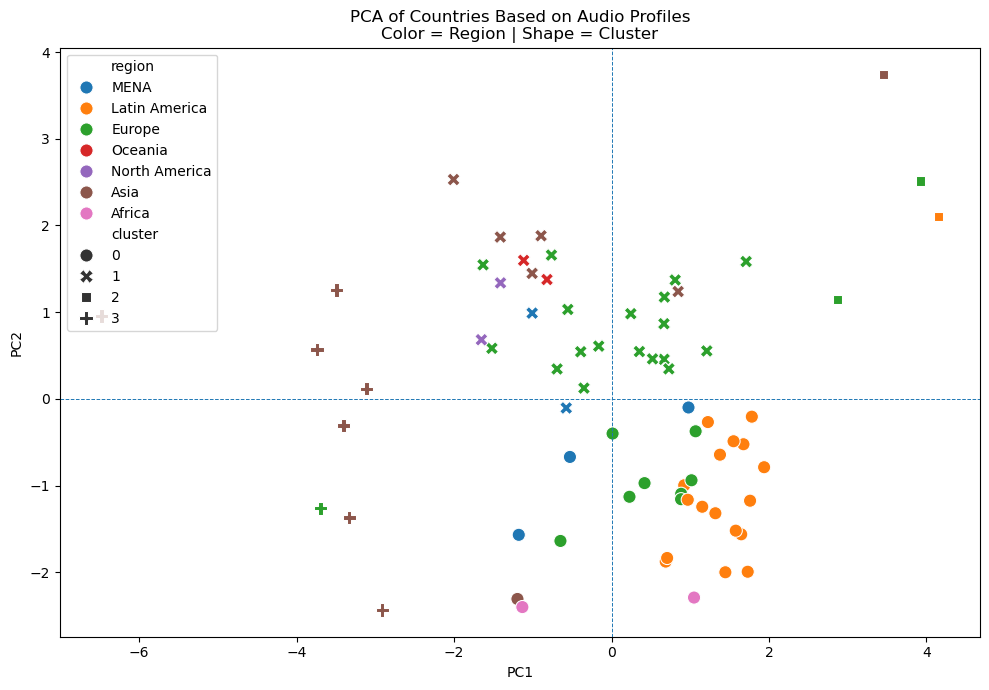

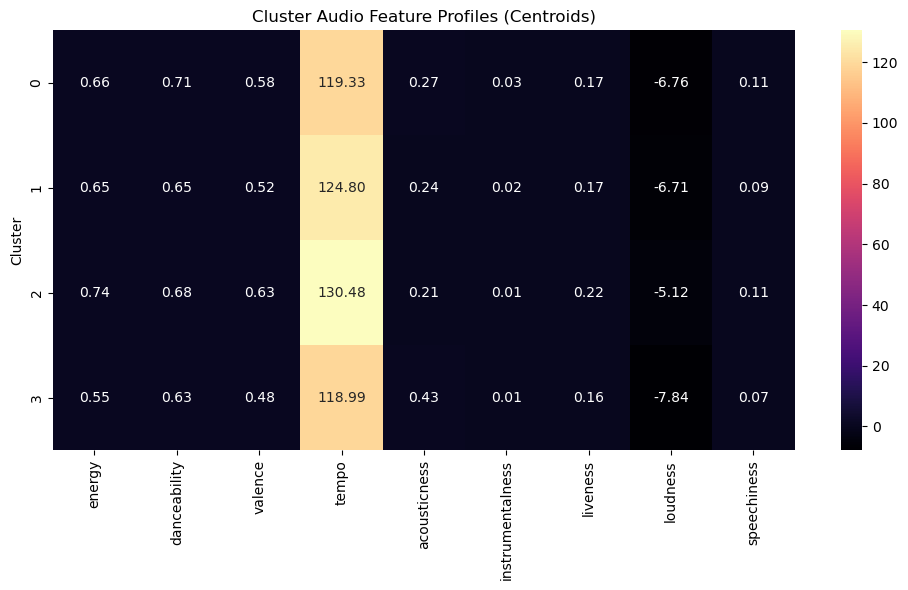


=== Countries per Cluster ===

Cluster 0:
   country         region
1       AR  Latin America
6       BO  Latin America
8       BY         Europe
11      CL  Latin America
12      CO  Latin America
13      CR  Latin America
17      DO  Latin America
18      EC  Latin America
20      EG           MENA
21      ES         Europe
23      FR         Europe
25      GR         Europe
26      GT  Latin America
28      HN  Latin America
29      HU         Europe
38      KZ           Asia
39      LT         Europe
42      MA           MENA
43      MX  Latin America
45      NG         Africa
46      NI  Latin America
50      PA  Latin America
51      PE  Latin America
55      PT         Europe
56      PY  Latin America
58      SA           MENA
62      SV  Latin America
66      UA         Europe
68      UY  Latin America
69      VE  Latin America
71      ZA         Africa

Cluster 1:
   country         region
0       AE           MENA
2       AT         Europe
3       AU        Oceania
4       B

In [49]:
# ============================================================
#   KMEANS + PCA — Final Clean Version
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------- SCALE FEATURES ----------------
X_country = country_features[audio_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_country)

# ---------------- KMEANS MODEL ----------------
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
country_features["cluster"] = kmeans.fit_predict(X_scaled)

# ---------------- PCA FOR VISUALIZATION ----------------
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
country_features["PC1"] = pcs[:,0]
country_features["PC2"] = pcs[:,1]

# ---------------- PLOT PCA ----------------
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=country_features,
    x="PC1", y="PC2",
    hue="region", style="cluster", s=90
)
plt.axhline(0, linestyle="--", linewidth=0.7)
plt.axvline(0, linestyle="--", linewidth=0.7)
plt.title("PCA of Countries Based on Audio Profiles\nColor = Region | Shape = Cluster")
plt.tight_layout()
plt.show()


# ============================================================
#   CLUSTER CENTROID HEATMAP  (SUPER IMPORTANT)
# ============================================================

cluster_profiles = (
    country_features.groupby("cluster")[audio_features].mean().round(3)
)

plt.figure(figsize=(10,6))
sns.heatmap(cluster_profiles, annot=True, cmap="magma", fmt=".2f")
plt.title("Cluster Audio Feature Profiles (Centroids)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


# ---------------- SUMMARY — PRINT CLUSTERS ----------------
print("\n=== Countries per Cluster ===")
for c in range(k):
    print(f"\nCluster {c}:")
    print(country_features.loc[country_features.cluster == c, ["country","region"]])

print("\n=== Region vs Cluster ===")
print(pd.crosstab(country_features.region, country_features.cluster))

print("\n=== CENTROID VALUES (use these for interpretation) ===")
print(cluster_profiles)


=== Logistic Regression (RQ5) ===
Accuracy: 0.9621080720480321

Classification report:
              precision    recall  f1-score   support

           0      0.962     1.000     0.981      7211
           1      0.000     0.000     0.000       284

    accuracy                          0.962      7495
   macro avg      0.481     0.500     0.490      7495
weighted avg      0.926     0.962     0.944      7495

Confusion matrix:
[[7211    0]
 [ 284    0]]

Logistic Regression Coefficients / Odds Ratios (RQ5):
            feature   coef  odds_ratio
2          loudness  0.272       1.313
4  instrumentalness  0.068       1.071
6             tempo -0.047       0.954
3           valence -0.097       0.908
1      danceability -0.142       0.867
7      acousticness -0.172       0.842
5       speechiness -0.178       0.837
0            energy -0.271       0.762


C:\Users\sebas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sebas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sebas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== Random Forest (RQ5) ===
Accuracy: 0.9633088725817212

Classification report:
              precision    recall  f1-score   support

           0      0.965     0.998     0.981      7211
           1      0.629     0.077     0.138       284

    accuracy                          0.963      7495
   macro avg      0.797     0.538     0.560      7495
weighted avg      0.952     0.963     0.949      7495

Confusion matrix:
[[7198   13]
 [ 262   22]]

Random Forest feature importances (RQ5):
            feature  importance
2          loudness       0.142
6             tempo       0.139
3           valence       0.133
7      acousticness       0.132
5       speechiness       0.128
1      danceability       0.128
0            energy       0.122
4  instrumentalness       0.077


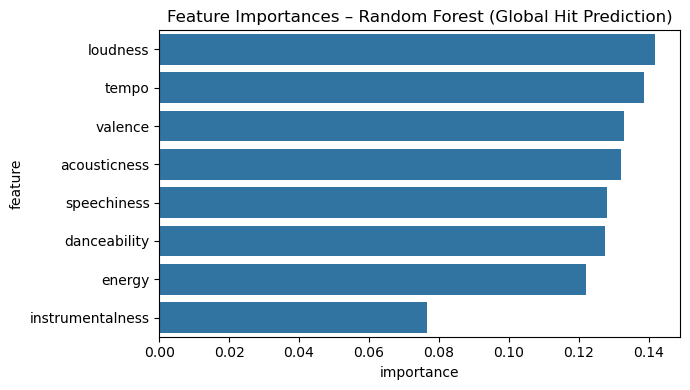

In [50]:
# Target: canción global (>=10 países)
song_level["global_hit"] = (song_level["num_countries"] >= 10).astype(int)

features_rq5 = [
    "energy",
    "danceability",
    "loudness",
    "valence",
    "instrumentalness",
    "speechiness",
    "tempo",
    "acousticness",
]

X_rq5 = song_level[features_rq5].copy()
y_rq5 = song_level["global_hit"]

# Drop missing
mask = X_rq5.notnull().all(axis=1) & y_rq5.notnull()
X_rq5 = X_rq5[mask]
y_rq5 = y_rq5[mask]

X_train_rq5, X_test_rq5, y_train_rq5, y_test_rq5 = train_test_split(
    X_rq5, y_rq5, test_size=0.3, random_state=42, stratify=y_rq5
)

# --- Logistic Regression ---
scaler_rq5 = StandardScaler()
X_train_scaled_rq5 = scaler_rq5.fit_transform(X_train_rq5)
X_test_scaled_rq5 = scaler_rq5.transform(X_test_rq5)

log_reg_rq5 = LogisticRegression(max_iter=1000)
log_reg_rq5.fit(X_train_scaled_rq5, y_train_rq5)

y_pred_lr_rq5 = log_reg_rq5.predict(X_test_scaled_rq5)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n=== Logistic Regression (RQ5) ===")
print("Accuracy:", accuracy_score(y_test_rq5, y_pred_lr_rq5))
print("\nClassification report:")
print(classification_report(y_test_rq5, y_pred_lr_rq5, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test_rq5, y_pred_lr_rq5))

coef_df_rq5 = pd.DataFrame({
    "feature": features_rq5,
    "coef": log_reg_rq5.coef_[0],
})
coef_df_rq5["odds_ratio"] = np.exp(coef_df_rq5["coef"])
print("\nLogistic Regression Coefficients / Odds Ratios (RQ5):")
print(coef_df_rq5.sort_values(by="odds_ratio", ascending=False))

# --- Random Forest ---
rf_rq5 = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_rq5.fit(X_train_rq5, y_train_rq5)

y_pred_rf_rq5 = rf_rq5.predict(X_test_rq5)

print("\n=== Random Forest (RQ5) ===")
print("Accuracy:", accuracy_score(y_test_rq5, y_pred_rf_rq5))
print("\nClassification report:")
print(classification_report(y_test_rq5, y_pred_rf_rq5, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test_rq5, y_pred_rf_rq5))

fi_rq5 = pd.DataFrame({
    "feature": features_rq5,
    "importance": rf_rq5.feature_importances_,
}).sort_values(by="importance", ascending=False)

print("\nRandom Forest feature importances (RQ5):")
print(fi_rq5)

plt.figure(figsize=(7, 4))
sns.barplot(data=fi_rq5, x="importance", y="feature")
plt.title("Feature Importances – Random Forest (Global Hit Prediction)")
plt.tight_layout()
plt.show()



Total December streams for classic Christmas artists:
artists
Michael Bublé    216480
Mariah Carey     200884
Wham!            177688
Name: popularity, dtype: int64

Top December Christmas tracks (artist, track, total streams):
artists        name                                       
Mariah Carey   All I Want for Christmas Is You                192927
Michael Bublé  It's Beginning to Look a Lot like Christmas    117210
Wham!          Last Christmas - Single Version                100511
Michael Bublé  Holly Jolly Christmas                           95695
Wham!          Last Christmas                                  77177
Mariah Carey   Christmas (Baby Please Come Home)                7560
Michael Bublé  Santa Claus Is Coming to Town                    2325
               White Christmas                                   878
Mariah Carey   O Holy Night                                      397
Michael Bublé  Christmas (Baby Please Come Home)                 292
               Winter 

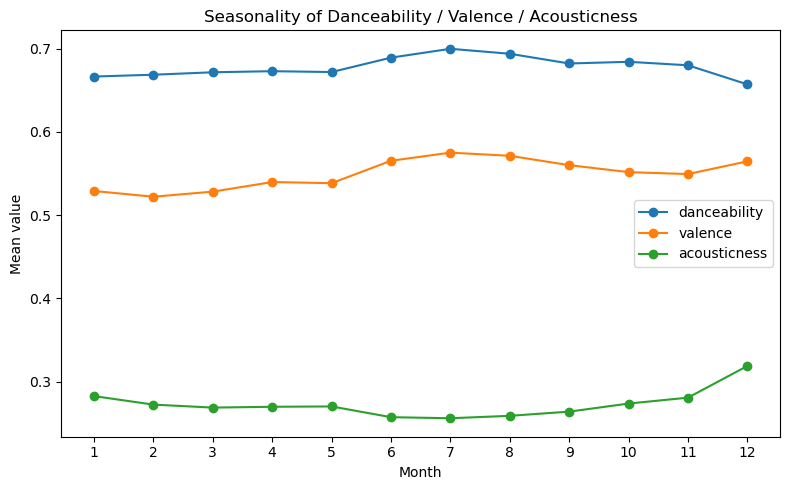


Summer vs non-summer (mean danceability / valence):
Summer:
 danceability   0.694
valence        0.570
dtype: float64

Non-summer:
 danceability   0.672
valence        0.541
dtype: float64

Valentine's window (Feb 10–20) vs rest of February:
Valentine's period:
 valence          0.520
acousticness     0.270
tempo          121.406
dtype: float64

Rest of February:
 valence          0.524
acousticness     0.274
tempo          121.829
dtype: float64


In [51]:
#rq6
# Detectar columna de fecha
if "date" in df.columns:
    date_col = "date"
elif "snapshot_date" in df.columns:
    date_col = "snapshot_date"
else:
    raise ValueError("No date column found. Please check column names.")

df[date_col] = pd.to_datetime(df[date_col])

df["year"] = df[date_col].dt.year
df["month"] = df[date_col].dt.month
df["day"] = df[date_col].dt.day

# Streams o proxy de popularidad
if "streams" in df.columns:
    streams_col = "streams"
elif "popularity" in df.columns:
    streams_col = "popularity"
else:
    raise ValueError("No streams or popularity column found.")

# ---------- December (Christmas) ----------
df_dec = df[df["month"] == 12].copy()

# Top artistas navideños como ejemplo
christmas_artists = ["Michael Bublé", "Mariah Carey", "Wham!"]

dec_christmas_artists = (
    df_dec[df_dec["artists"].isin(christmas_artists)]
    .groupby("artists")[streams_col]
    .sum()
    .sort_values(ascending=False)
)

print("\nTotal December streams for classic Christmas artists:")
print(dec_christmas_artists)

# Top canciones navideñas por streams en diciembre
dec_christmas_tracks = (
    df_dec[df_dec["artists"].isin(christmas_artists)]
    .groupby(["artists", "name"])[streams_col]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)
print("\nTop December Christmas tracks (artist, track, total streams):")
print(dec_christmas_tracks)

# Número de países en los que aparecen estas canciones en diciembre
dec_christmas_countries = (
    df_dec[df_dec["artists"].isin(christmas_artists)]
    .groupby(["artists", "name"])["country"]
    .nunique()
    .sort_values(ascending=False)
)
print("\nNumber of countries where Christmas tracks appear in December:")
print(dec_christmas_countries.head(20))

# ---------- Seasonality of audio features ----------
monthly_audio = (
    df.groupby("month")[["danceability", "valence", "acousticness"]]
    .mean()
    .reset_index()
)

print("\nMonthly average danceability / valence / acousticness:")
print(monthly_audio)

plt.figure(figsize=(8, 5))
for col in ["danceability", "valence", "acousticness"]:
    plt.plot(monthly_audio["month"], monthly_audio[col], marker="o", label=col)
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Mean value")
plt.title("Seasonality of Danceability / Valence / Acousticness")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Summer (Jun–Aug) vs rest ----------
summer = df[df["month"].isin([6, 7, 8])]
non_summer = df[~df["month"].isin([6, 7, 8])]

summer_stats = summer[["danceability", "valence"]].mean()
non_summer_stats = non_summer[["danceability", "valence"]].mean()

print("\nSummer vs non-summer (mean danceability / valence):")
print("Summer:\n", summer_stats)
print("\nNon-summer:\n", non_summer_stats)

# ---------- Valentine’s period (Feb 10–20) ----------
val_period = df[(df["month"] == 2) & (df["day"].between(10, 20))]
non_val_feb = df[(df["month"] == 2) & (~df["day"].between(10, 20))]

val_stats = val_period[["valence", "acousticness", "tempo"]].mean()
non_val_stats = non_val_feb[["valence", "acousticness", "tempo"]].mean()

print("\nValentine's window (Feb 10–20) vs rest of February:")
print("Valentine's period:\n", val_stats)
print("\nRest of February:\n", non_val_stats)
